Step 1: Calculating Risk-Free Rate and Forward Rates
To determine the risk-free rate, we use the US Treasury yield curve data. For each interval of length 
Δ𝑡, we calculate the forward rates, which represent the annualized interest rate for future periods.

Zero Rate at Maturity 0.75: 4.3858%


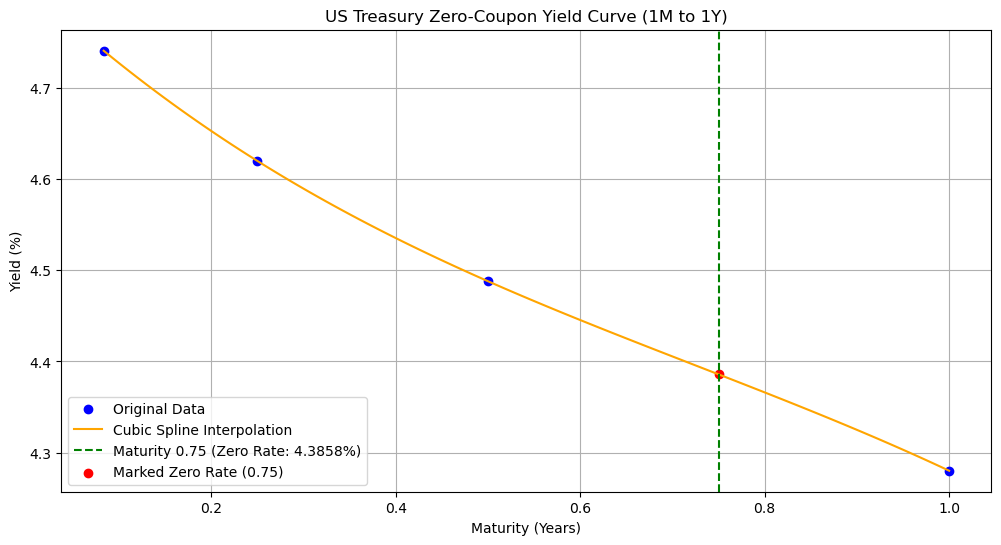

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Input data for US Treasury yields from
data = {
    '1M': 4.741,  # 1-month yield (%)
    '3M': 4.620,  # 3-month yield (%)
    '6M': 4.488,  # 6-month yield (%)
    '1Y': 4.280   # 1-year yield (%)
}

# Create DataFrame
df = pd.DataFrame(list(data.items()), columns=['Maturity', 'Yield'])
df['Yield'] /= 100  # Convert to decimal form
maturity_years = {'1M': 1 / 12, '3M': 0.25, '6M': 0.5, '1Y': 1}
df['Years'] = df['Maturity'].map(maturity_years)

# Zero Rate Calculation (directly using yields as zero rates)
df['Zero Rate'] = df['Yield']

# Cubic Spline Interpolation
cs = CubicSpline(df['Years'], df['Zero Rate'])

# Create fine-grained maturity points and interpolated zero rates
fine_years = np.linspace(min(df['Years']), max(df['Years']), 100)
interpolated_rates = cs(fine_years)

# Define get_zero_rate function
def get_zero_rate(maturity):
    """Return the zero rate for a given maturity using cubic spline interpolation."""
    clamped_maturity = max(min(maturity, max(df['Years'])), min(df['Years']))
    return cs(clamped_maturity)

def get_forward_rate(maturity, dt):
    """
    Calculate the forward rate for the interval (maturity-dt, maturity).

    Parameters:
    - maturity: The upper bound of the interval (e.g., time t2).
    - dt: The time interval (e.g., maturity - dt defines time t1).
    - get_zero_rate: Function to fetch the zero rate for a given maturity.

    Returns:
    - Forward rate for the interval (maturity - dt, maturity).
    """
    if maturity < dt:
        raise ValueError("Maturity must be greater than or equal to dt.")
    
    t1 = maturity - dt
    t2 = maturity

    # Zero rates at t1 and t2
    z1 = get_zero_rate(t1)
    z2 = get_zero_rate(t2)

    # Calculate the forward rate
    # forward_rate = ((1 + z2) ** t2 / (1 + z1) ** t1) ** (1 / dt) - 1
    forward_rate = (t2 * z2 - t1 * z1) / dt
    return forward_rate

def calculate_forward_rates(max_maturity, dt):
    """
    Calculate a list of forward rates for intervals of size dt up to max_maturity.

    Parameters:
    - max_maturity: The total maturity (e.g., 1 year).
    - dt: The size of each time interval.

    Returns:
    - forward_rates: List of forward rates for each interval.
    """
    num_intervals = int(max_maturity / dt)
    forward_rates = []

    for i in range(1, num_intervals + 1):
        maturity = i * dt
        forward_rate = get_forward_rate(maturity, dt)
        forward_rates.append(forward_rate)

    return forward_rates

# Marking the zero rate at maturity 0.75
maturity_to_mark = 0.75
zero_rate_at_mark = cs(maturity_to_mark)

# Display the zero rate at maturity 0.75
print(f"Zero Rate at Maturity 0.75: {zero_rate_at_mark * 100:.4f}%")

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(df['Years'], df['Zero Rate'] * 100, 'o', label='Original Data', color='blue')
plt.plot(fine_years, interpolated_rates * 100, '-', label='Cubic Spline Interpolation', color='orange')
plt.axvline(maturity_to_mark, color='green', linestyle='--', label=f'Maturity 0.75 (Zero Rate: {zero_rate_at_mark * 100:.4f}%)')
plt.scatter([maturity_to_mark], [zero_rate_at_mark * 100], color='red', label='Marked Zero Rate (0.75)')
plt.title('US Treasury Zero-Coupon Yield Curve (1M to 1Y)')
plt.xlabel('Maturity (Years)')
plt.ylabel('Yield (%)')
plt.legend()
plt.grid(True)
plt.show()


Step 2: Estimating Volatility Using ARIMA-GARCH Model
To accurately estimate the volatility of an asset, we combine the ARIMA model for capturing the time series dynamics of returns with the GARCH model for modeling time-varying volatility. This approach allows us to separate the mean dynamics from the volatility structure, providing a more robust volatility estimation.

[*********************100%***********************]  1 of 1 completed


ADF Test Result:
Test Statistic: -15.8419
p-value: 0.0000
Critical Values: {'1%': -3.456780859712, '5%': -2.8731715065600003, '10%': -2.572968544}
데이터는 정상성을 만족합니다.


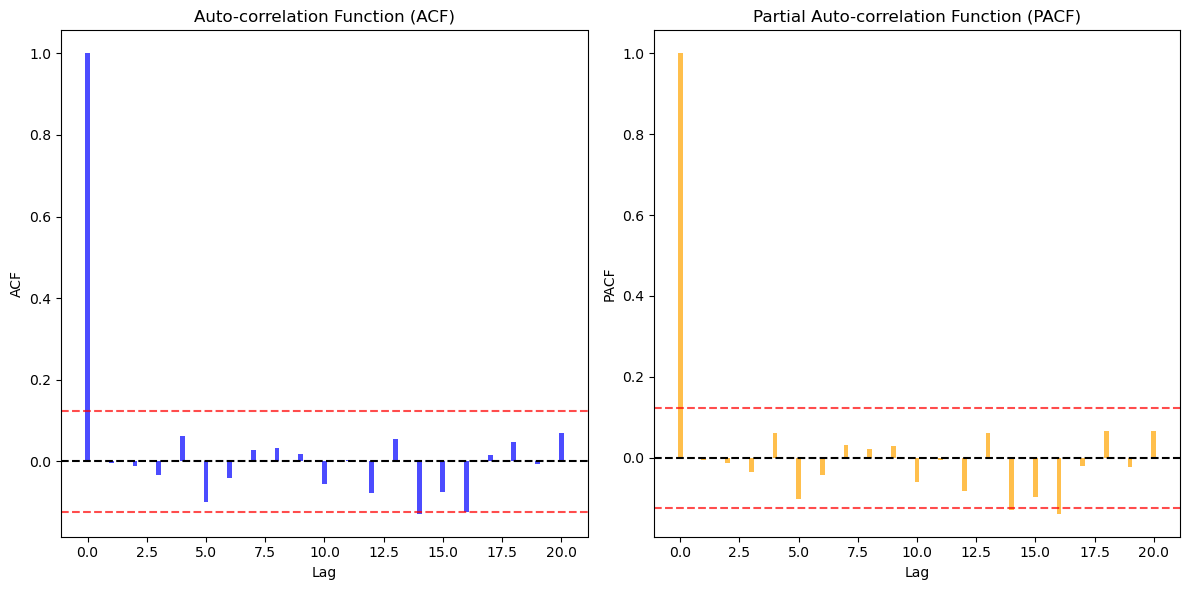

c:\Users\yejun\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\yejun\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\yejun\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\yejun\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive pa

Iteration:      1,   Func. Count:      6,   Neg. LLF: 128292067.22016007
Iteration:      2,   Func. Count:     17,   Neg. LLF: -872.9592456045343
Optimization terminated successfully    (Exit mode 0)
            Current function value: -872.9592458696991
            Iterations: 6
            Function evaluations: 17
            Gradient evaluations: 2


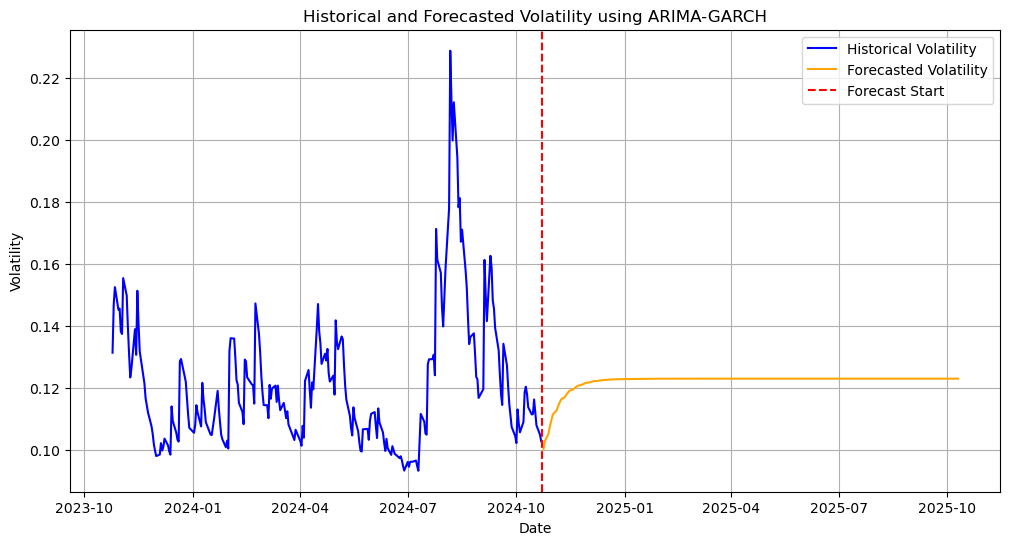

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
from arch import arch_model
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
import matplotlib.pyplot as plt

# Step 1: 데이터 준비
ticker = "^GSPC"
start_date = "2023-10-23"
end_date = "2024-10-23"

# S&P 500 데이터 가져오기
data = yf.download(ticker, start=start_date, end=end_date)
data['Log Returns'] = np.log(data['Close'] / data['Close'].shift(1))
data = data[np.isfinite(data['Log Returns'])]

# Step 2: 정상성 테스트 (ADF Test)
adf_result = adfuller(data['Log Returns'])
print("ADF Test Result:")
print(f"Test Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"Critical Values: {adf_result[4]}")
if adf_result[1] < 0.05:
    print("데이터는 정상성을 만족합니다.")
else:
    print("데이터는 정상성을 만족하지 않습니다. 차분이 필요합니다.")

# Step 3: ACF 및 PACF 그래프 시각화
acf_values = acf(data['Log Returns'], nlags=20, fft=True)
pacf_values = pacf(data['Log Returns'], nlags=20)

plt.figure(figsize=(12, 6))

# ACF 그래프
plt.subplot(121)
plt.bar(range(len(acf_values)), acf_values, width=0.2, color='blue', alpha=0.7)
plt.axhline(y=0, linestyle='--', color='black')
plt.axhline(y=1.96/np.sqrt(len(data['Log Returns'])), linestyle='--', color='red', alpha=0.7) # 1.96 from 95% confidence level
plt.axhline(y=-1.96/np.sqrt(len(data['Log Returns'])), linestyle='--', color='red', alpha=0.7)
plt.title('Auto-correlation Function (ACF)')
plt.xlabel('Lag')
plt.ylabel('ACF')

# PACF 그래프
plt.subplot(122)
plt.bar(range(len(pacf_values)), pacf_values, width=0.2, color='orange', alpha=0.7)
plt.axhline(y=0, linestyle='--', color='black')
plt.axhline(y=1.96/np.sqrt(len(data['Log Returns'])), linestyle='--', color='red', alpha=0.7)
plt.axhline(y=-1.96/np.sqrt(len(data['Log Returns'])), linestyle='--', color='red', alpha=0.7)
plt.title('Partial Auto-correlation Function (PACF)')
plt.xlabel('Lag')
plt.ylabel('PACF')

plt.tight_layout()
plt.show()

# Step 4: ARIMA 모델 피팅
arima_model = ARIMA(data['Log Returns'], order=(1, 0, 1))
arima_fit = arima_model.fit()

# 잔차(Residuals) 추출
arima_residuals = arima_fit.resid

# Step 5: GARCH 모델 피팅
garch_model = arch_model(arima_residuals, vol='Garch', p=1, q=1)
garch_fit = garch_model.fit()

# Step 6: 미래 변동성 예측
forecast_horizon = 252  # 1년
garch_forecast = garch_fit.forecast(horizon=forecast_horizon)

# 조건부 변동성 추정
# 과거 변동성
conditional_volatility_daily = garch_fit.conditional_volatility.iloc[1:]  # 일 단위 변동성
conditional_volatility_annualized = conditional_volatility_daily * np.sqrt(252) # 연 단위로 변환
# 미래 변동성
future_volatility_daily = np.sqrt(garch_forecast.variance.values[-1]) # 일 단위 미래 변동성
future_volatility_annualized = future_volatility_daily * np.sqrt(252) # 연 단위로 변환

# Step 7: 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(data.index[1:], conditional_volatility_annualized, label='Historical Volatility', color='blue')
future_dates = pd.date_range(start=end_date, periods=forecast_horizon + 1, freq='B')[1:]
plt.plot(future_dates, future_volatility_annualized, label='Forecasted Volatility', color='orange')
plt.axvline(x=pd.Timestamp(end_date), color='red', linestyle='--', label='Forecast Start')
plt.title('Historical and Forecasted Volatility using ARIMA-GARCH')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()


Step 3: Calculate Parameters for Binomial Tree Model (𝑢,𝑑,𝑝)

In [4]:
import numpy as np

num_periods = 252  # Total number of periods (daily intervals for 1 year)
T = 1  # Maturity in years
dt = T / num_periods  # Time step size in years

def calculate_parameters_by_interval(volatilities, forward_rates, dt):
    """
    Calculate the parameters u, d, and p for each interval in the binomial tree, 
    considering dynamic volatilities and forward rates.

    Parameters:
    - volatilities: A list or array of annualized volatilities for each time step.
    - forward_rates: A list or array of forward rates for each time step.
    - dt: Time step size in years (Delta t).

    Returns:
    - u_values: List of up factors for each time interval.
    - d_values: List of down factors for each time interval.
    - p_values: List of risk-neutral probabilities for each time interval.
    """
    # Calculate average volatility (root mean square)
    avg_volatility = np.sqrt(np.mean(np.array(volatilities) ** 2))
    
    # Calculate u and d
    u = np.exp(avg_volatility * np.sqrt(dt))
    d = 1 / u

    p_values = []
    for f_rate in forward_rates:
        # Calculate risk-neutral probability for the current interval
        p = (np.exp(f_rate * dt) - d) / (u - d)
        p_values.append(p)

    return u, d, p_values

volatilities = future_volatility_annualized
forward_rates = calculate_forward_rates(T,dt)
u, d, p_values = calculate_parameters_by_interval(volatilities, forward_rates, dt)

# time invariant u, d for recombining condition

Step 4: Bond Pricing Using CRR Binomial Tree Model

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
#import networkx as nx

# Define S&P 500 ticker
ticker = "^GSPC"  # S&P 500 index

# Fetch historical data for the desired date (10/23/2024)
data = yf.Ticker(ticker).history(start="2024-10-22", end="2024-10-23")

# Check if data is fetched
if not data.empty:
    S0 = data['Close'].iloc[0]  # Get the closing price of S&P 500 on 10/23/2024
    print(f"S&P 500 Closing Price on 10/23/2024: {S0:.2f}")
else:
    print("Data for 10/23/2024 is not available. Please verify the date or data source.")
    S0 = 4300.50  # Fallback to a default value if data is unavailable
    print(f"Using fallback value for S&P 500: {S0:.2f}")

# Calculate discount rate
def discount_rate(t):
    return np.exp(-get_forward_rate(t*dt,dt) * dt)

def bond_valuation_CRR_ver1(S0, u, d, p_values, num_periods):
    """
    CRR(재결합) 바이노미얼 트리를 활용하여 채권 가치를 계산합니다.
    """

    # **재결합 트리 생성: 자산 가격**
    asset_tree = np.zeros((num_periods + 1, num_periods + 1))
    for t in range(num_periods + 1):
        for i in range(t + 1):
            # 자산 가격 계산: S_t = S_0 * u^(t-i) * d^i
            asset_tree[t, i] = S0 * (u ** (t - i)) * (d ** i)

    # **현금흐름 트리 초기화**
    cash_flows = np.zeros((num_periods + 1, num_periods + 1))
    cash_flows[-1, :] = 100  # 만기 시 원금 100 지급

    # **쿠폰 지급 시점 정의**
    coupon_times = [int(num_periods * t / T) for t in [0.25, 0.5, 0.75, 1.0]]  # 3M, 6M, 9M, 1Y

    # **역방향 계산(Backward Induction)**
    for t in range(num_periods - 1, -1, -1):
        for i in range(t + 1):
            S_curr = asset_tree[t, i]
            S_up = asset_tree[t + 1, i]
            S_down = asset_tree[t + 1, i + 1]

            # **쿠폰 계산: up과 down 각각 계산**
            coupon_up = 0
            coupon_down = 0
            if t + 1 in coupon_times:
                # 누적 수익률 계산 (up)
                cumulative_return_up = (S_up / S0) - 1
                if cumulative_return_up > 0.1:
                    coupon_up = 0.2 * 0.25 * 100
                elif cumulative_return_up > 0:
                    coupon_up = cumulative_return_up * 2 * 0.25 * 100
                else:
                    coupon_up = cumulative_return_up * 0.5 * 0.25 * 100

                # 누적 수익률 계산 (down)
                cumulative_return_down = (S_down / S0) - 1
                if cumulative_return_down > 0.1:
                    coupon_down = 0.2 * 0.25 * 100
                elif cumulative_return_down > 0:
                    coupon_down = cumulative_return_down * 2 * 0.25 * 100
                else:
                    coupon_down = cumulative_return_down * 0.5 * 0.25 * 100

            # **기대 현금흐름 계산**
            expected_cash_flow = (
                p_values[t] * (coupon_up + cash_flows[t + 1, i]) +
                (1 - p_values[t]) * (coupon_down + cash_flows[t + 1, i + 1])
            ) * discount_rate(t + 1)  # 할인율 적용
            cash_flows[t, i] = expected_cash_flow

    # **결과 반환**
    return cash_flows, asset_tree

# Test the bond valuation function
cash_flows_ver1, asset_tree_ver1 = bond_valuation_CRR_ver1(S0, u, d, p_values, num_periods)
print(f"Fair Price of the Bond: ${cash_flows_ver1[0][0]:.2f}")

S&P 500 Closing Price on 10/23/2024: 5851.20
Fair Price of the Bond: $102.02


In [7]:
def bond_valuation_CRR_ver2(S0, u, d, p_values, num_periods):
    """
    CRR 바이노미얼 트리를 4개의 구간(interval)으로 나누어 채권 가치를 계산합니다.
    각 구간에서 별도의 바이노미얼 트리를 생성합니다.
    """

    # 구간별 기간 계산 (3개월 간격)
    intervals = 4
    periods_per_interval = num_periods // intervals  # 각 구간의 기간 수

    # 전체 현금흐름 트리 초기화
    total_cash_flows = np.zeros((num_periods + 1, num_periods + 1))
    discounted_cash_flows = []  # 각 구간의 시작 시점의 현금흐름의 현재 가치

    # 각 구간의 트리 생성 및 계산
    for interval in range(intervals):
        # 각 구간의 시작 시점과 끝 시점
        start = interval * periods_per_interval
        end = (interval + 1) * periods_per_interval
        start_time = start * dt
        # 자산 가격 트리 초기화
        asset_tree = np.zeros((periods_per_interval + 1, periods_per_interval + 1))
        for t in range(periods_per_interval + 1):
            for i in range(t + 1):
                # 자산 가격 계산
                asset_tree[t, i] = S0 * (u ** (t - i)) * (d ** i)

        # 현금흐름 트리 초기화
        cash_flows = np.zeros((periods_per_interval + 1, periods_per_interval + 1))

        # 마지막 구간의 만기에서 원금 100 지급
        if interval == intervals - 1:
            cash_flows[-1, :] = 100

        # 역방향 계산 (Backward Induction)
        for t in range(periods_per_interval - 1, -1, -1):
            for i in range(t + 1):
                S_curr = asset_tree[t, i]
                S_up = asset_tree[t + 1, i]
                S_down = asset_tree[t + 1, i + 1]

                # 쿠폰 계산
                coupon_up = 0
                coupon_down = 0
                if t + 1 == periods_per_interval:  # 구간 끝에서 쿠폰 지급
                    cumulative_return_up = (S_up / S0) - 1
                    if cumulative_return_up > 0.1:
                        coupon_up = 0.2 * 0.25 * 100
                    elif cumulative_return_up > 0:
                        coupon_up = cumulative_return_up * 2 * 0.25 * 100
                    else:
                        coupon_up = cumulative_return_up * 0.5 * 0.25 * 100

                    cumulative_return_down = (S_down / S0) - 1
                    if cumulative_return_down > 0.1:
                        coupon_down = 0.2 * 0.25 * 100
                    elif cumulative_return_down > 0:
                        coupon_down = cumulative_return_down * 2 * 0.25 * 100
                    else:
                        coupon_down = cumulative_return_down * 0.5 * 0.25 * 100

                # 기대 현금흐름 계산
                expected_cash_flow = (
                    p_values[start + t] * (coupon_up + cash_flows[t + 1, i]) +
                    (1 - p_values[start + t]) * (coupon_down + cash_flows[t + 1, i + 1])
                ) * discount_rate(start + t + 1)
                cash_flows[t, i] = expected_cash_flow

        # 전체 현금흐름 트리에 이번 구간의 현금흐름 추가
        for t in range(periods_per_interval + 1):
            for i in range(t + 1):
                total_cash_flows[start + t, i] += cash_flows[t, i]

        # 이번 구간의 시작 시점의 현금흐름의 현재 가치
        discounted_value = cash_flows[0,0] * np.exp(-get_zero_rate(start_time) * start_time)
        discounted_cash_flows.append(discounted_value)
        
    # **결과 반환**
    return total_cash_flows, discounted_cash_flows

# Test the bond valuation function
cash_flows_ver2, discounted_cash_flows = bond_valuation_CRR_ver2(S0, u, d, p_values, num_periods)
fair_price_ver2 = np.sum(discounted_cash_flows)
print(f"Fair Price of the Bond: ${fair_price_ver2:.2f}")

Fair Price of the Bond: $100.29


Step 5: Calculate the Greek Letter, Delta

In [139]:
def calculate_delta_ver1(cash_flows, asset_tree):
    """
    Calculate the Greek delta (Δ) for each state in the binomial tree.
    
    Parameters:
    - cash_flows: 2D numpy array of bond values at each state (from bond_valuation_CRR).
    - asset_tree: 2D numpy array of asset prices at each state (from bond_valuation_CRR).
    
    Returns:
    - delta_tree: 2D numpy array with delta values for each state.
    """
    num_periods = cash_flows.shape[0] - 1
    delta_tree = np.zeros_like(cash_flows)

    # Iterate over all levels except the last (no delta at maturity)
    for t in range(num_periods):
        for i in range(t + 1):
            # Get values for up and down states
            V_up = cash_flows[t + 1, i]
            V_down = cash_flows[t + 1, i + 1]
            S_up = asset_tree[t + 1, i]
            S_down = asset_tree[t + 1, i + 1]

            # Calculate delta
            delta_tree[t, i] = (V_up - V_down) / (S_up - S_down)

    return delta_tree

# Calculate delta
delta_tree_ver1 = calculate_delta_ver1(cash_flows_ver1, asset_tree_ver1)

# Print only the delta value for the first node (t=0, i=0)
delta_0_0 = delta_tree_ver1[0][0]
print(f"Delta[0][0]: {delta_0_0}")

Delta[0][0]: 0.06592716904210993


In [21]:
def calculate_delta_ver2():
    perturbation = 10
    cash_flows_ver2, discounted_cash_flows = bond_valuation_CRR_ver2(S0, u, d, p_values, num_periods)
    fair_price_ver2_1 = np.sum(discounted_cash_flows)

    cash_flows_ver2, discounted_cash_flows = bond_valuation_CRR_ver2(S0 + perturbation, u, d, p_values, num_periods)
    fair_price_ver2_2 = np.sum(discounted_cash_flows)
    
    delta = (fair_price_ver2_2 - fair_price_ver2_1) / perturbation
    return delta

delta = calculate_delta_ver2()
print(f"Delta[0][0]: {delta}")


Delta[0][0]: 1.4210854715202005e-15
